# Phase 4 : Exploratory Data Analysis (EDA)
## Système d'Aide à la Décision — Fidélisation Client E-commerce

---
**Objectif :** Comprendre les données à travers des analyses et visualisations des ventes, clients, produits, satisfaction et livraison.

---

## 4.1 - Imports et Chargement des Données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pandas.plotting import scatter_matrix
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('\u2713 Librairies import\u00e9es avec succ\u00e8s')

✓ Librairies importées avec succès


In [3]:
# ===========================================================
# MODIFIER CES CHEMINS SELON VOTRE MACHINE
# ===========================================================
BASE_PATH  = r"C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD"
OLIST_PATH = BASE_PATH + r"\Brazilian E-Commerce Public Dataset by Olist"

# Chargement du dataset analytique final produit en Phase 3
ca = pd.read_csv('customer_analytics.csv')
ca['first_order_date'] = pd.to_datetime(ca['first_order_date'])
ca['last_order_date']  = pd.to_datetime(ca['last_order_date'])

# Rechargement des tables brutes Olist
olist_orders      = pd.read_csv(f"{OLIST_PATH}/olist_orders_dataset.csv")
olist_order_items = pd.read_csv(f"{OLIST_PATH}/olist_order_items_dataset.csv")
olist_payments    = pd.read_csv(f"{OLIST_PATH}/olist_order_payments_dataset.csv")
olist_reviews     = pd.read_csv(f"{OLIST_PATH}/olist_order_reviews_dataset.csv")
olist_products    = pd.read_csv(f"{OLIST_PATH}/olist_products_dataset.csv")
olist_customers   = pd.read_csv(f"{OLIST_PATH}/olist_customers_dataset.csv")
olist_category    = pd.read_csv(f"{OLIST_PATH}/product_category_name_translation.csv")

# Conversion des colonnes de dates en datetime
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    olist_orders[col] = pd.to_datetime(olist_orders[col], errors='coerce')

print('\u2713 Donn\u00e9es charg\u00e9es')
print(f'  customer_analytics : {ca.shape[0]:,} clients \u00d7 {ca.shape[1]} features')

✓ Données chargées
  customer_analytics : 93,350 clients × 19 features


## 4.2 - Analyse des Ventes

In [4]:
# =============================================================
# PREPARATION : dataset commandes livrees avec paiements
# =============================================================

# Filtrer uniquement les commandes livrees
orders_delivered = olist_orders[olist_orders['order_status'] == 'delivered'].copy()

# Agregation des paiements par commande (somme des paiements fractionnes)
payments_agg = olist_payments.groupby('order_id')['payment_value'].sum().reset_index()
payments_agg.columns = ['order_id', 'total_payment']

# Jointure commandes + paiements
orders_full = orders_delivered.merge(payments_agg, on='order_id', how='left')

# Variables temporelles pour analyses de tendance
orders_full['order_month']     = orders_full['order_purchase_timestamp'].dt.to_period('M')
orders_full['order_year']      = orders_full['order_purchase_timestamp'].dt.year
orders_full['order_month_num'] = orders_full['order_purchase_timestamp'].dt.month

print(f'\u2713 Dataset ventes pr\u00e9par\u00e9 : {orders_full.shape[0]:,} commandes livr\u00e9es')

✓ Dataset ventes préparé : 96,478 commandes livrées


In [5]:
# =============================================================
# KPIs VENTES GLOBAUX
# =============================================================
ca_total     = orders_full['total_payment'].sum()
nb_commandes = orders_full['order_id'].nunique()
panier_moyen = ca_total / nb_commandes

print('=' * 55)
print('  KPIs VENTES GLOBAUX')
print('=' * 55)
print(f"  Chiffre d'affaires total : {ca_total:>15,.2f} BRL")
print(f"  Nombre de commandes      : {nb_commandes:>15,}")
print(f"  Panier moyen             : {panier_moyen:>15,.2f} BRL")

  KPIs VENTES GLOBAUX
  Chiffre d'affaires total :   15,422,461.77 BRL
  Nombre de commandes      :          96,478
  Panier moyen             :          159.85 BRL


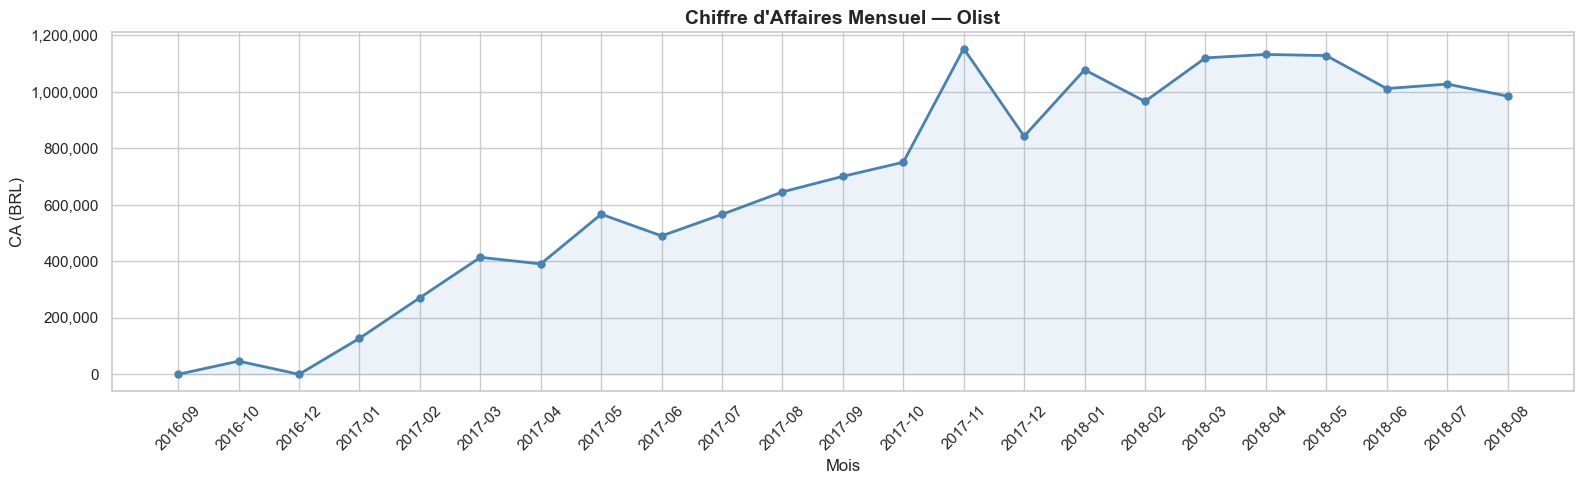

✓ eda_ca_mensuel.png sauvegardé


In [6]:
# =============================================================
# CA MENSUEL — evolution dans le temps
# =============================================================
ca_mensuel = (
    orders_full.groupby('order_month')['total_payment']
    .sum()
    .reset_index()
)
ca_mensuel['order_month_str'] = ca_mensuel['order_month'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ca_mensuel['order_month_str'], ca_mensuel['total_payment'],
        marker='o', color='steelblue', linewidth=2, markersize=5)
ax.fill_between(range(len(ca_mensuel)), ca_mensuel['total_payment'],
                alpha=0.1, color='steelblue')
ax.set_title("Chiffre d'Affaires Mensuel \u2014 Olist", fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('CA (BRL)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_ca_mensuel.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_ca_mensuel.png sauvegard\u00e9')

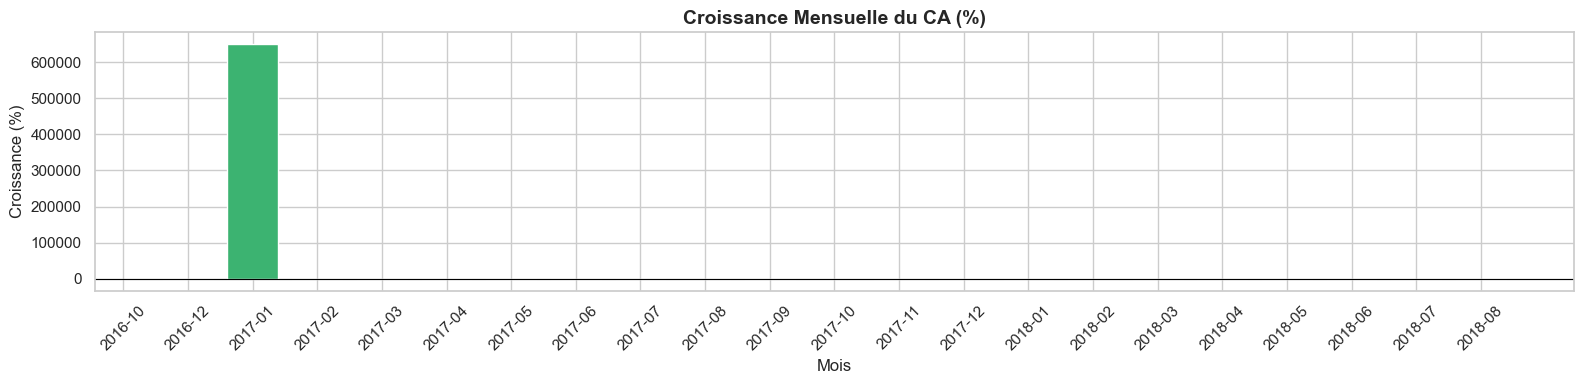

✓ eda_croissance_ca.png sauvegardé


In [7]:
# =============================================================
# CROISSANCE MENSUELLE DU CA (%)
# Barres vertes = croissance positive, rouges = decroissance
# =============================================================
ca_mensuel['croissance_pct'] = ca_mensuel['total_payment'].pct_change() * 100

fig, ax = plt.subplots(figsize=(16, 4))
colors = ['mediumseagreen' if v >= 0 else 'salmon'
          for v in ca_mensuel['croissance_pct'].fillna(0)]
ax.bar(ca_mensuel['order_month_str'], ca_mensuel['croissance_pct'],
       color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Croissance Mensuelle du CA (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Croissance (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_croissance_ca.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_croissance_ca.png sauvegard\u00e9')

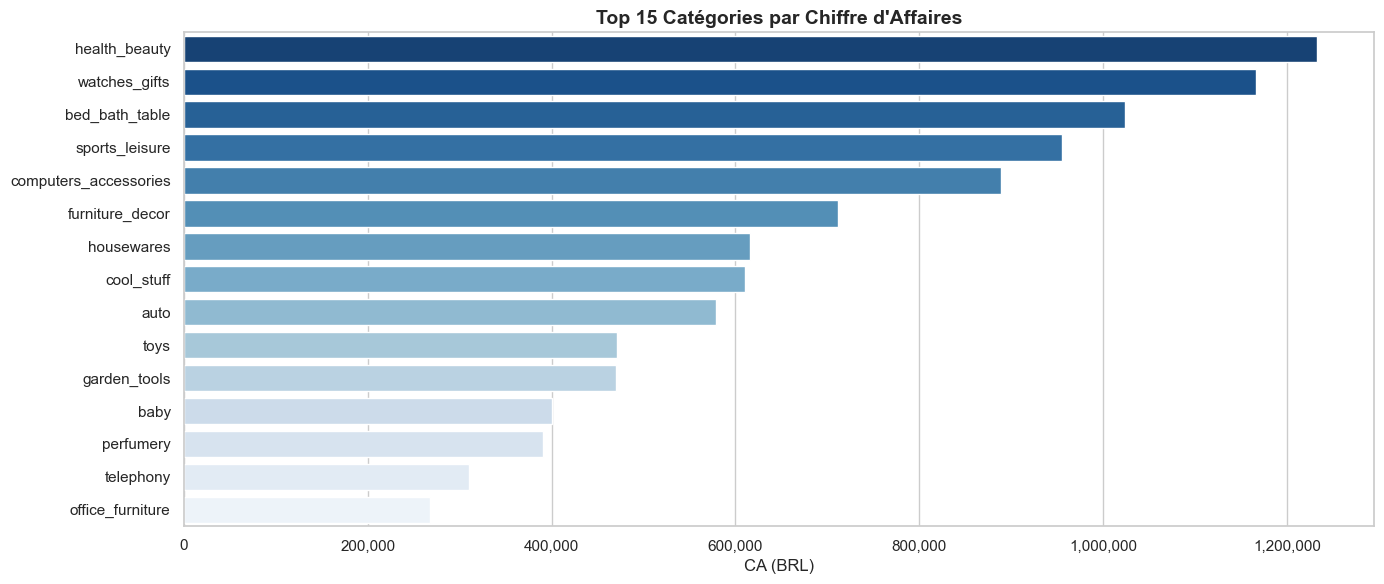

✓ eda_ca_categorie.png sauvegardé


In [8]:
# =============================================================
# CA PAR CATEGORIE DE PRODUIT
# Jointure items + produits + traduction categories
# =============================================================

# Jointure items avec infos produits
items_products = olist_order_items.merge(
    olist_products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)
# Ajout de la traduction anglaise des categories
items_products = items_products.merge(olist_category, on='product_category_name', how='left')

# Restriction aux commandes livrees uniquement
items_delivered = items_products.merge(
    orders_delivered[['order_id']], on='order_id', how='inner'
)

# CA par categorie (top 15)
ca_categorie = (
    items_delivered.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
ca_categorie.columns = ['categorie', 'ca']

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=ca_categorie, y='categorie', x='ca', palette='Blues_r', ax=ax)
ax.set_title("Top 15 Cat\u00e9gories par Chiffre d'Affaires", fontsize=14, fontweight='bold')
ax.set_xlabel('CA (BRL)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_ca_categorie.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_ca_categorie.png sauvegard\u00e9')

## 4.3 - Analyse Clients

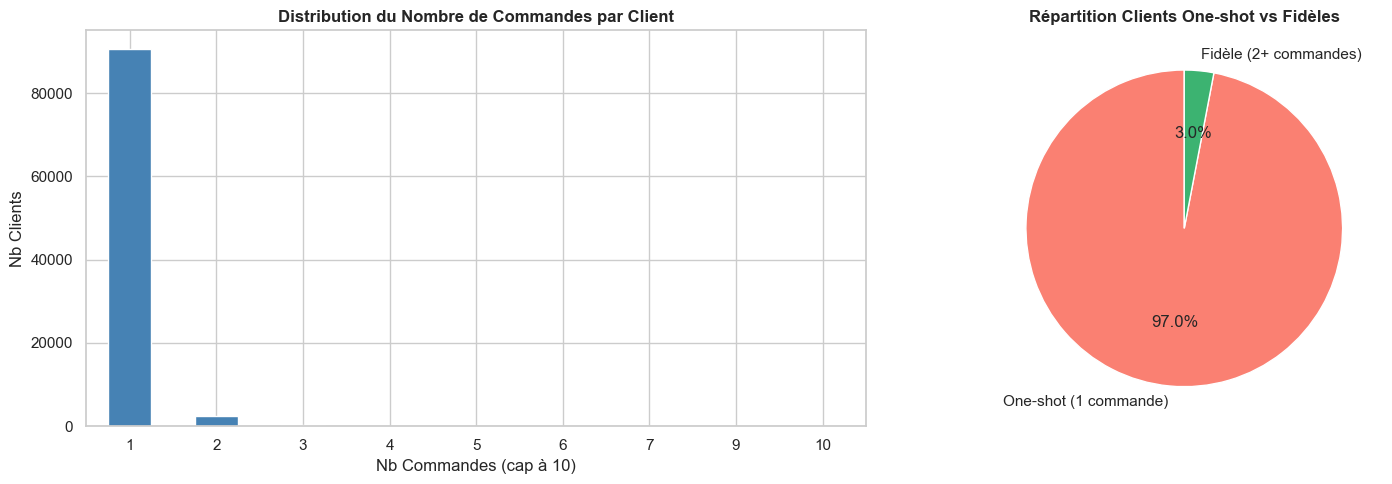

✓ eda_distribution_clients.png sauvegardé


In [9]:
# =============================================================
# DISTRIBUTION DES CLIENTS PAR NOMBRE DE COMMANDES
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme nb commandes (cap a 10 pour lisibilite)
(
    ca['nb_orders'].clip(upper=10)
    .value_counts()
    .sort_index()
    .plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
)
axes[0].set_title('Distribution du Nombre de Commandes par Client',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nb Commandes (cap \u00e0 10)')
axes[0].set_ylabel('Nb Clients')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart one-shot vs fidele
loyal_counts = ca['is_loyal'].value_counts()
axes[1].pie(
    loyal_counts.values,
    labels=['One-shot (1 commande)', 'Fid\u00e8le (2+ commandes)'],
    autopct='%1.1f%%',
    colors=['salmon', 'mediumseagreen'],
    startangle=90,
    wedgeprops=dict(edgecolor='white')
)
axes[1].set_title('R\u00e9partition Clients One-shot vs Fid\u00e8les',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_distribution_clients.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_distribution_clients.png sauvegard\u00e9')

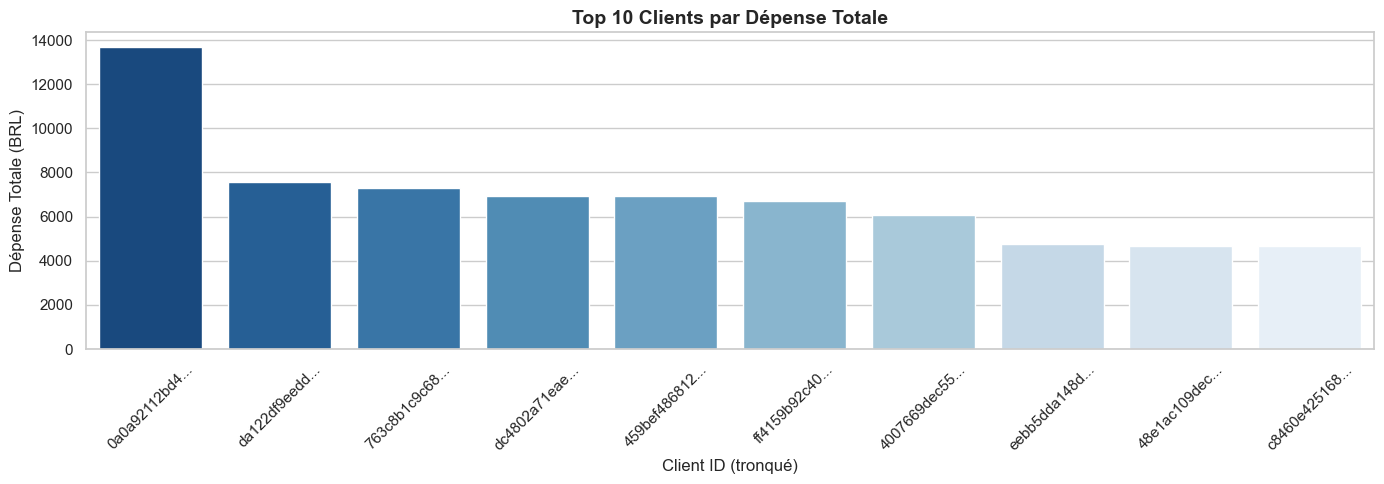

✓ eda_top_clients.png sauvegardé


In [10]:
# =============================================================
# TOP 10 CLIENTS PAR DEPENSE TOTALE
# =============================================================
top_clients = ca.nlargest(10, 'total_spent')[
    ['customer_unique_id', 'total_spent', 'nb_orders', 'avg_review_score']
].copy()
# Tronquer l'ID pour lisibilite
top_clients['customer_unique_id'] = top_clients['customer_unique_id'].str[:12] + '...'

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=top_clients, x='customer_unique_id', y='total_spent',
            palette='Blues_r', ax=ax)
ax.set_title('Top 10 Clients par D\u00e9pense Totale', fontsize=14, fontweight='bold')
ax.set_xlabel('Client ID (tronqu\u00e9)')
ax.set_ylabel('D\u00e9pense Totale (BRL)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_top_clients.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_top_clients.png sauvegard\u00e9')

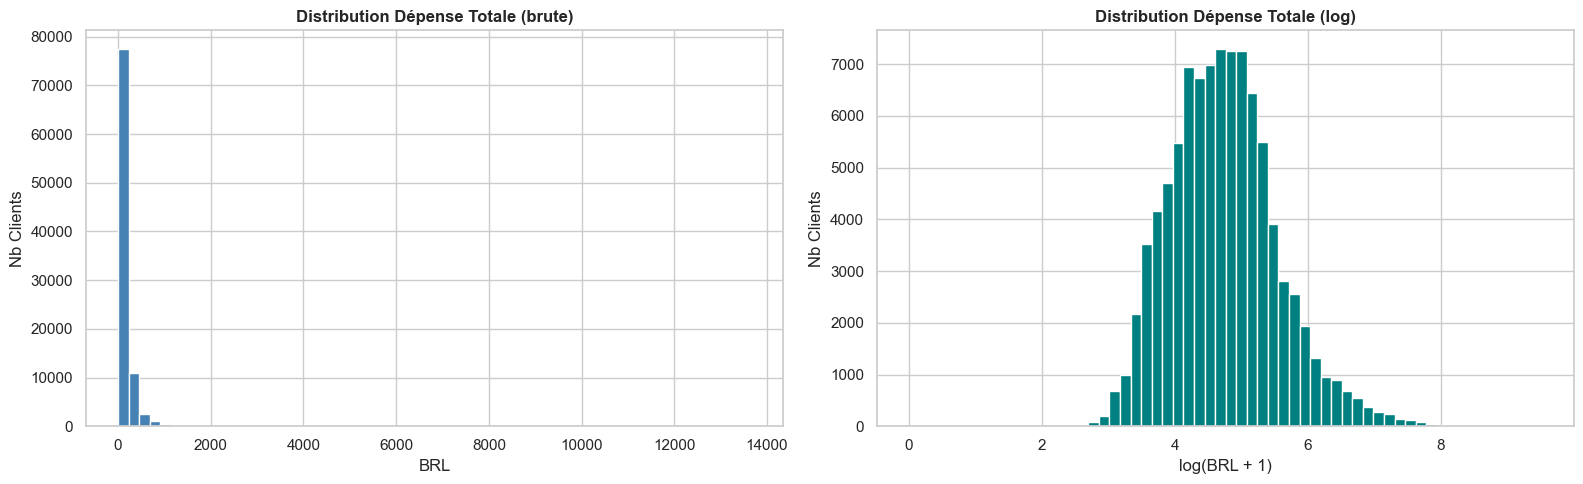

✓ eda_distribution_depenses.png sauvegardé


In [11]:
# =============================================================
# DISTRIBUTION DES DEPENSES (brute + log scale)
# La distribution log permet de mieux voir la forme reelle
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(ca['total_spent'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution D\u00e9pense Totale (brute)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BRL')
axes[0].set_ylabel('Nb Clients')

axes[1].hist(np.log1p(ca['total_spent']), bins=60, color='teal', edgecolor='white')
axes[1].set_title('Distribution D\u00e9pense Totale (log)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(BRL + 1)')
axes[1].set_ylabel('Nb Clients')

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_distribution_depenses.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_distribution_depenses.png sauvegard\u00e9')

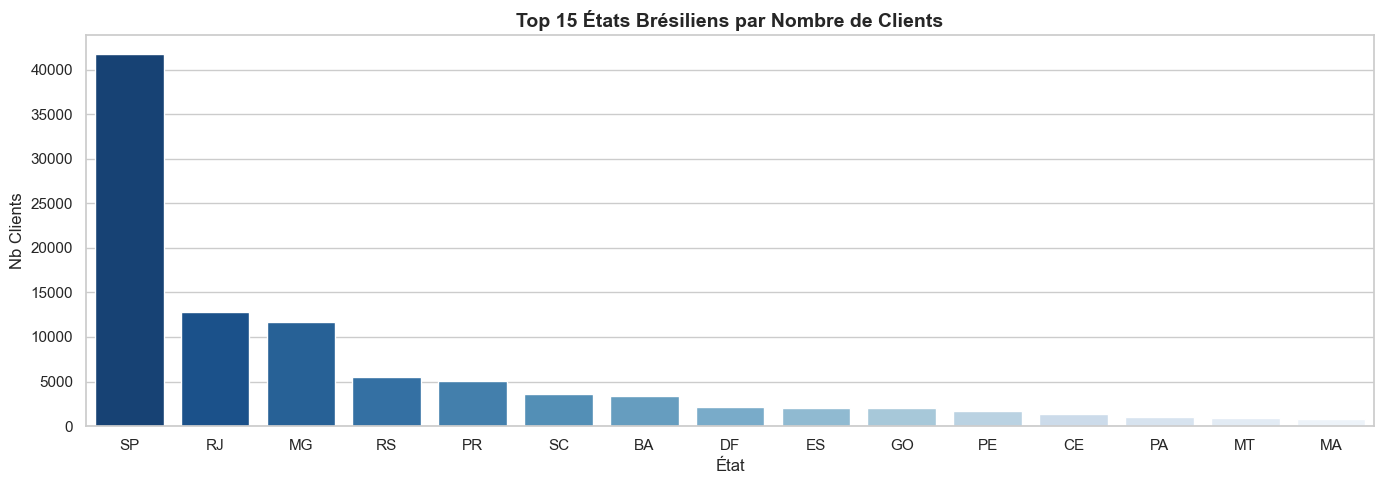

✓ eda_clients_par_etat.png sauvegardé


In [12]:
# =============================================================
# CLIENTS PAR ETAT BRESILIEN
# =============================================================
clients_par_etat = (
    olist_customers['customer_state']
    .value_counts()
    .head(15)
    .reset_index()
)
clients_par_etat.columns = ['state', 'nb_clients']

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=clients_par_etat, x='state', y='nb_clients', palette='Blues_r', ax=ax)
ax.set_title('Top 15 \u00c9tats Br\u00e9siliens par Nombre de Clients',
             fontsize=14, fontweight='bold')
ax.set_xlabel('\u00c9tat')
ax.set_ylabel('Nb Clients')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_clients_par_etat.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_clients_par_etat.png sauvegard\u00e9')

## 4.4 - Analyse Produits

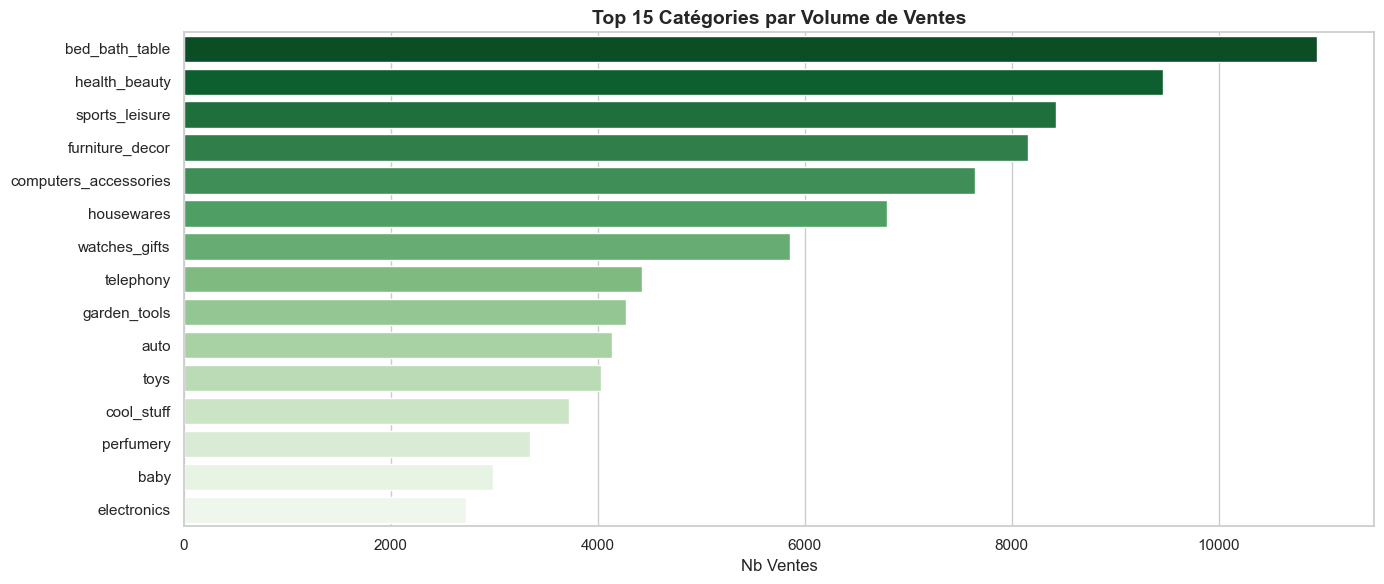

✓ eda_top_produits_volume.png sauvegardé


In [13]:
# =============================================================
# TOP 15 CATEGORIES PAR VOLUME DE VENTES
# =============================================================
top_produits_qte = (
    items_delivered.groupby('product_category_name_english')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_produits_qte.columns = ['categorie', 'nb_ventes']

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=top_produits_qte, y='categorie', x='nb_ventes',
            palette='Greens_r', ax=ax)
ax.set_title('Top 15 Cat\u00e9gories par Volume de Ventes', fontsize=14, fontweight='bold')
ax.set_xlabel('Nb Ventes')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_top_produits_volume.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_top_produits_volume.png sauvegard\u00e9')

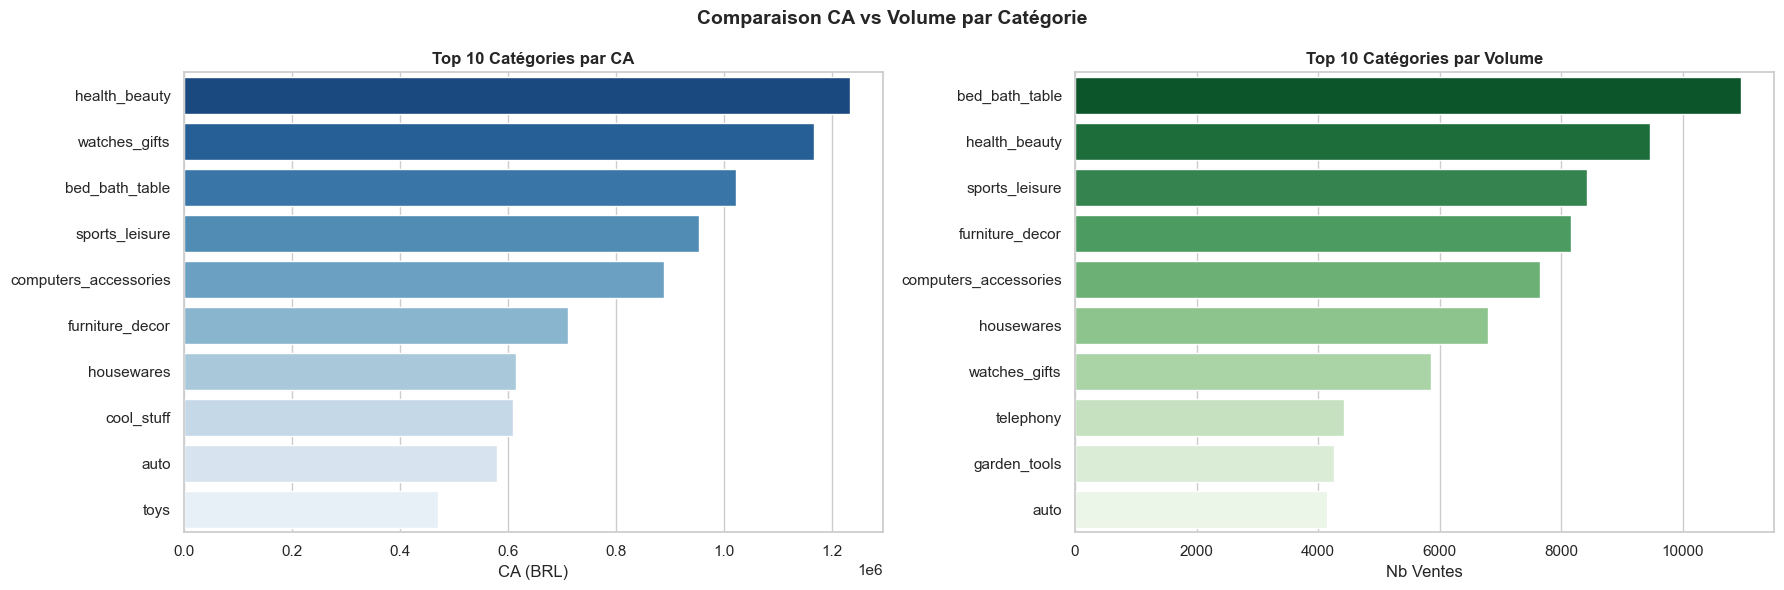

✓ eda_produits_ca_vs_volume.png sauvegardé


In [14]:
# =============================================================
# COMPARAISON CA vs VOLUME PAR CATEGORIE
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=ca_categorie.head(10), y='categorie', x='ca',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Cat\u00e9gories par CA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CA (BRL)')
axes[0].set_ylabel('')

sns.barplot(data=top_produits_qte.head(10), y='categorie', x='nb_ventes',
            palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Cat\u00e9gories par Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nb Ventes')
axes[1].set_ylabel('')

plt.suptitle('Comparaison CA vs Volume par Cat\u00e9gorie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_produits_ca_vs_volume.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_produits_ca_vs_volume.png sauvegard\u00e9')

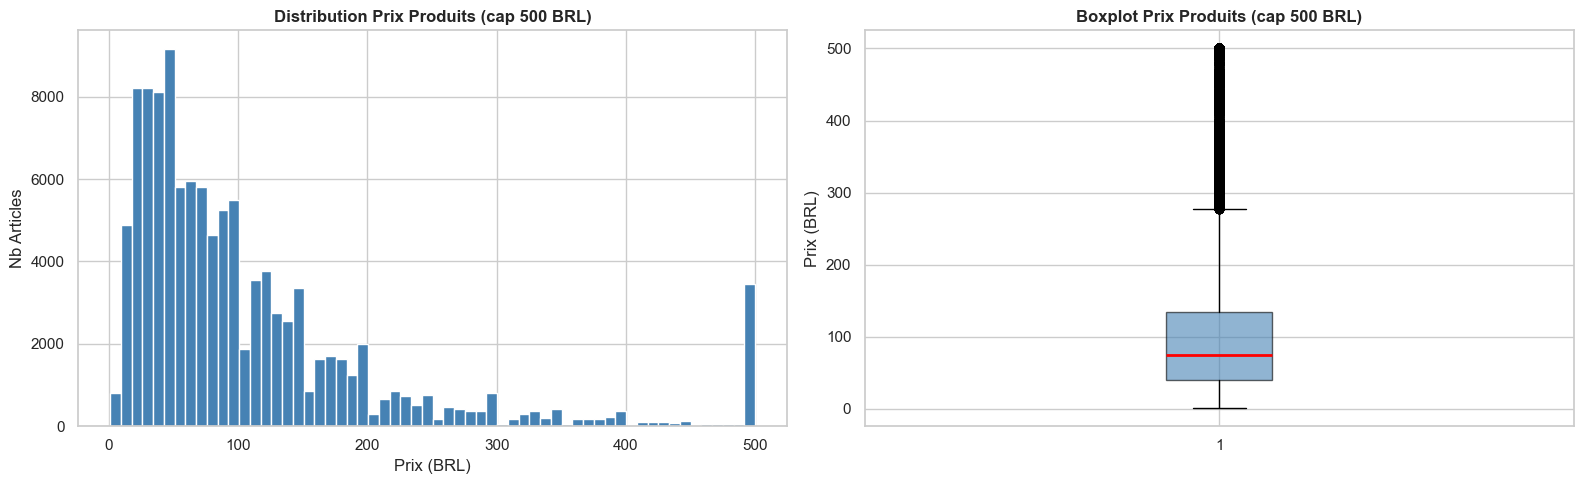

✓ eda_distribution_prix.png sauvegardé


In [15]:
# =============================================================
# DISTRIBUTION DU PRIX DES PRODUITS
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme cape a 500 BRL pour eviter l'effet des outliers extremes
axes[0].hist(olist_order_items['price'].clip(upper=500),
             bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution Prix Produits (cap 500 BRL)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prix (BRL)')
axes[0].set_ylabel('Nb Articles')

# Boxplot pour voir les quartiles et outliers
axes[1].boxplot(
    olist_order_items['price'].clip(upper=500),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Boxplot Prix Produits (cap 500 BRL)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prix (BRL)')

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_distribution_prix.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_distribution_prix.png sauvegard\u00e9')

## 4.5 - Analyse Satisfaction Client

  KPIs SATISFACTION CLIENT
  Note moyenne      : 4.09 / 5
  % Avis positifs   : 77.1%
  % Avis neutres    : 8.2%
  % Avis négatifs   : 14.7%


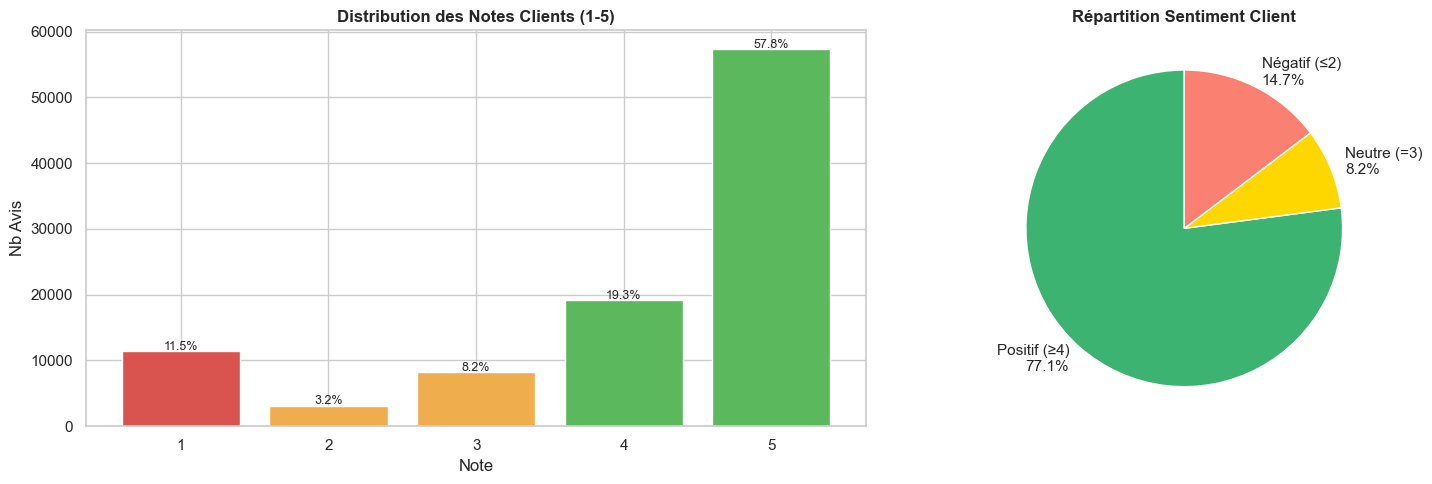

✓ eda_satisfaction.png sauvegardé


In [16]:
# =============================================================
# KPIs SATISFACTION + DISTRIBUTION DES NOTES
# =============================================================
olist_reviews_clean = olist_reviews.dropna(subset=['review_score']).copy()
olist_reviews_clean['review_score'] = olist_reviews_clean['review_score'].astype(int)
olist_reviews_clean = olist_reviews_clean[olist_reviews_clean['review_score'].between(1, 5)]

review_counts = olist_reviews_clean['review_score'].value_counts().sort_index()
pct_positif   = (olist_reviews_clean['review_score'] >= 4).mean() * 100
pct_negatif   = (olist_reviews_clean['review_score'] <= 2).mean() * 100
pct_neutre    = 100 - pct_positif - pct_negatif
note_moyenne  = olist_reviews_clean['review_score'].mean()

print('=' * 55)
print('  KPIs SATISFACTION CLIENT')
print('=' * 55)
print(f'  Note moyenne      : {note_moyenne:.2f} / 5')
print(f'  % Avis positifs   : {pct_positif:.1f}%')
print(f'  % Avis neutres    : {pct_neutre:.1f}%')
print(f'  % Avis n\u00e9gatifs   : {pct_negatif:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart distribution des notes avec annotation des pourcentages
colors_bar = ['#d9534f', '#f0ad4e', '#f0ad4e', '#5cb85c', '#5cb85c']
axes[0].bar(review_counts.index, review_counts.values,
            color=colors_bar, edgecolor='white')
axes[0].set_title('Distribution des Notes Clients (1-5)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nb Avis')
for score, count in review_counts.items():
    axes[0].text(score, count + 200,
                 f"{count/len(olist_reviews_clean)*100:.1f}%",
                 ha='center', fontsize=9)

# Pie chart positif / neutre / negatif
axes[1].pie(
    [pct_positif, pct_neutre, pct_negatif],
    labels=[f'Positif (\u22654)\n{pct_positif:.1f}%',
            f'Neutre (=3)\n{pct_neutre:.1f}%',
            f'N\u00e9gatif (\u22642)\n{pct_negatif:.1f}%'],
    colors=['mediumseagreen', 'gold', 'salmon'],
    startangle=90,
    wedgeprops=dict(edgecolor='white')
)
axes[1].set_title('R\u00e9partition Sentiment Client', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_satisfaction.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_satisfaction.png sauvegard\u00e9')

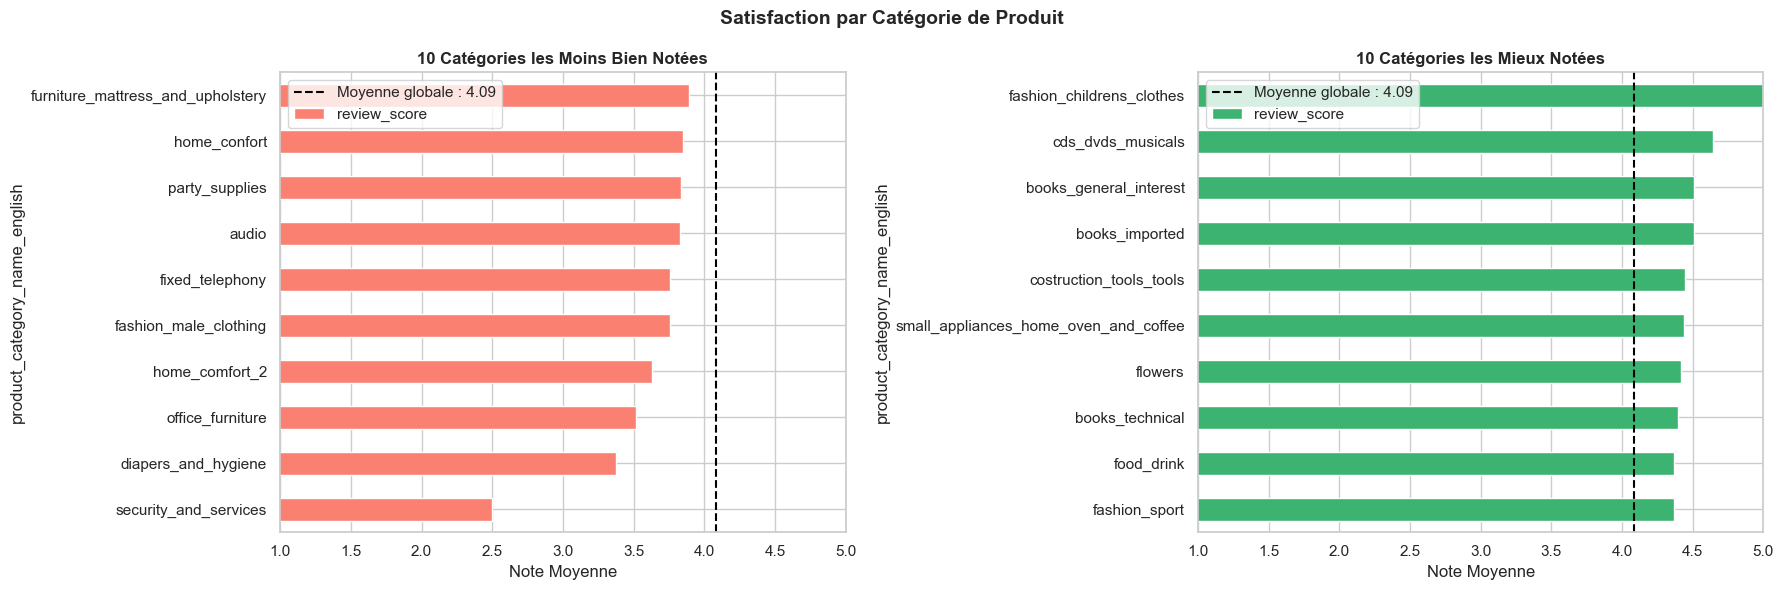

✓ eda_satisfaction_categorie.png sauvegardé


In [17]:
# =============================================================
# SATISFACTION MOYENNE PAR CATEGORIE DE PRODUIT
# Identifie les categories qui posent probleme
# =============================================================
reviews_items = items_delivered.merge(
    olist_reviews_clean[['order_id', 'review_score']],
    on='order_id', how='left'
)

satisfaction_cat = (
    reviews_items
    .groupby('product_category_name_english')['review_score']
    .mean()
    .dropna()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 10 moins bien notees
satisfaction_cat.head(10).plot(kind='barh', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('10 Cat\u00e9gories les Moins Bien Not\u00e9es', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Note Moyenne')
axes[0].set_xlim(1, 5)
axes[0].axvline(note_moyenne, color='black', linestyle='--',
                label=f'Moyenne globale : {note_moyenne:.2f}')
axes[0].legend()

# 10 mieux notees
satisfaction_cat.tail(10).plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('10 Cat\u00e9gories les Mieux Not\u00e9es', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Note Moyenne')
axes[1].set_xlim(1, 5)
axes[1].axvline(note_moyenne, color='black', linestyle='--',
                label=f'Moyenne globale : {note_moyenne:.2f}')
axes[1].legend()

plt.suptitle('Satisfaction par Cat\u00e9gorie de Produit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_satisfaction_categorie.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_satisfaction_categorie.png sauvegard\u00e9')

## 4.6 - Analyse Livraison

In [18]:
# =============================================================
# PREPARATION : variables de livraison
# =============================================================
orders_delivery = orders_full.copy()

# Retard : positif = en retard / negatif = en avance
orders_delivery['delivery_delay_days'] = (
    orders_delivery['order_delivered_customer_date'] -
    orders_delivery['order_estimated_delivery_date']
).dt.days

# Delai reel de livraison (achat -> livraison)
orders_delivery['actual_delivery_days'] = (
    orders_delivery['order_delivered_customer_date'] -
    orders_delivery['order_purchase_timestamp']
).dt.days

# Indicateur binaire de retard
orders_delivery['is_late'] = (orders_delivery['delivery_delay_days'] > 0).astype(int)

# Suppression des lignes avec dates manquantes
orders_delivery = orders_delivery.dropna(
    subset=['delivery_delay_days', 'actual_delivery_days']
)

delai_moyen  = orders_delivery['actual_delivery_days'].mean()
taux_retard  = orders_delivery['is_late'].mean() * 100
retard_moyen = orders_delivery.loc[
    orders_delivery['is_late'] == 1, 'delivery_delay_days'
].mean()

print('=' * 55)
print('  KPIs LIVRAISON')
print('=' * 55)
print(f'  D\u00e9lai moyen de livraison : {delai_moyen:.1f} jours')
print(f'  Taux de retard           : {taux_retard:.1f}%')
print(f'  Retard moyen (si retard) : {retard_moyen:.1f} jours')

  KPIs LIVRAISON
  Délai moyen de livraison : 12.1 jours
  Taux de retard           : 6.8%
  Retard moyen (si retard) : 10.6 jours


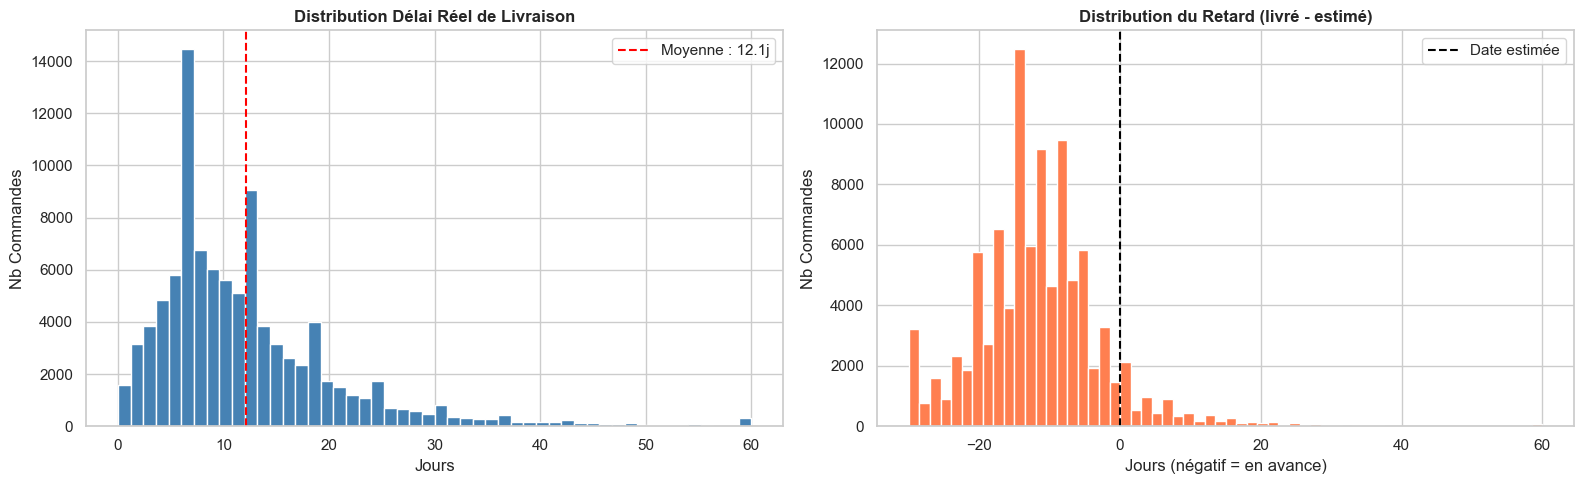

✓ eda_livraison_distribution.png sauvegardé


In [19]:
# =============================================================
# DISTRIBUTION DES DELAIS DE LIVRAISON
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Delai reel
axes[0].hist(orders_delivery['actual_delivery_days'].clip(upper=60),
             bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(delai_moyen, color='red', linestyle='--',
                label=f'Moyenne : {delai_moyen:.1f}j')
axes[0].set_title('Distribution D\u00e9lai R\u00e9el de Livraison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jours')
axes[0].set_ylabel('Nb Commandes')
axes[0].legend()

# Distribution du retard
axes[1].hist(orders_delivery['delivery_delay_days'].clip(-30, 60),
             bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', label='Date estim\u00e9e')
axes[1].set_title('Distribution du Retard (livr\u00e9 - estim\u00e9)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jours (n\u00e9gatif = en avance)')
axes[1].set_ylabel('Nb Commandes')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_livraison_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_livraison_distribution.png sauvegard\u00e9')

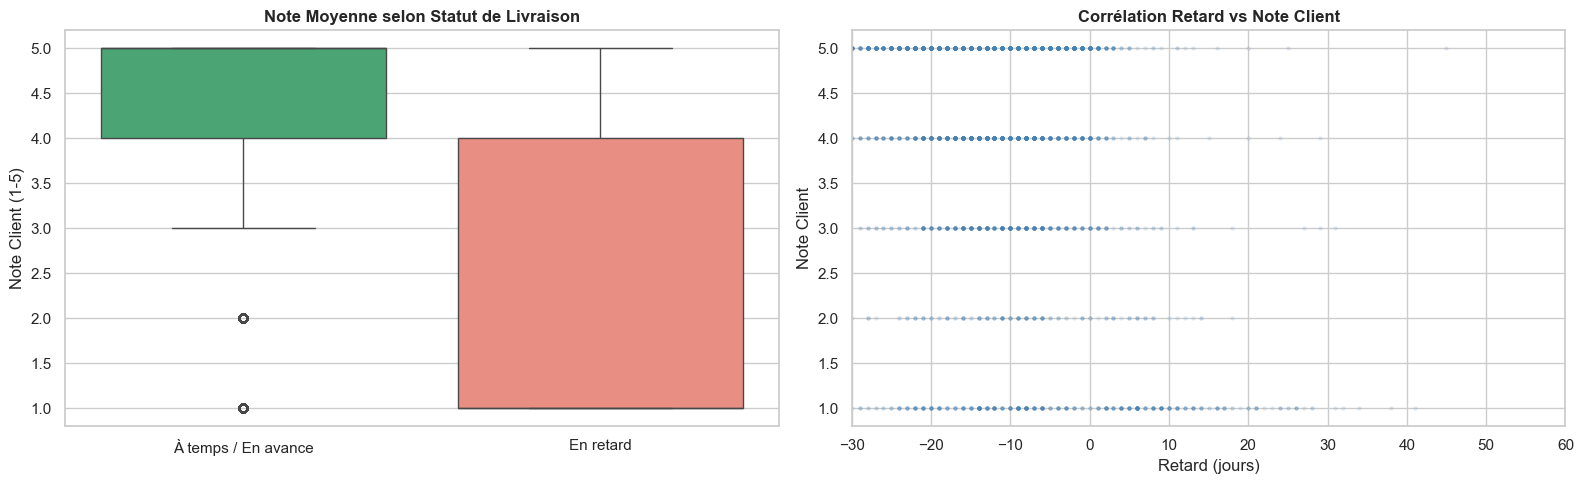

✓ eda_retard_vs_satisfaction.png sauvegardé


In [20]:
# =============================================================
# IMPACT DU RETARD SUR LA SATISFACTION CLIENT
# =============================================================
orders_reviews = orders_delivery.merge(
    olist_reviews_clean[['order_id', 'review_score']],
    on='order_id', how='left'
).dropna(subset=['review_score'])

# Label lisible pour le statut de livraison
orders_reviews['statut_livraison'] = orders_reviews['is_late'].map(
    {0: '\u00c0 temps / En avance', 1: 'En retard'}
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot note selon retard ou non
sns.boxplot(
    data=orders_reviews, x='statut_livraison', y='review_score',
    palette={'\u00c0 temps / En avance': 'mediumseagreen', 'En retard': 'salmon'},
    ax=axes[0]
)
axes[0].set_title('Note Moyenne selon Statut de Livraison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Note Client (1-5)')

# Scatter plot correlation retard vs note (echantillon pour performances)
sample = orders_reviews.sample(min(5000, len(orders_reviews)), random_state=42)
axes[1].scatter(sample['delivery_delay_days'], sample['review_score'],
                alpha=0.1, color='steelblue', s=5)
axes[1].set_title('Corr\u00e9lation Retard vs Note Client', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Retard (jours)')
axes[1].set_ylabel('Note Client')
axes[1].set_xlim(-30, 60)

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_retard_vs_satisfaction.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_retard_vs_satisfaction.png sauvegard\u00e9')

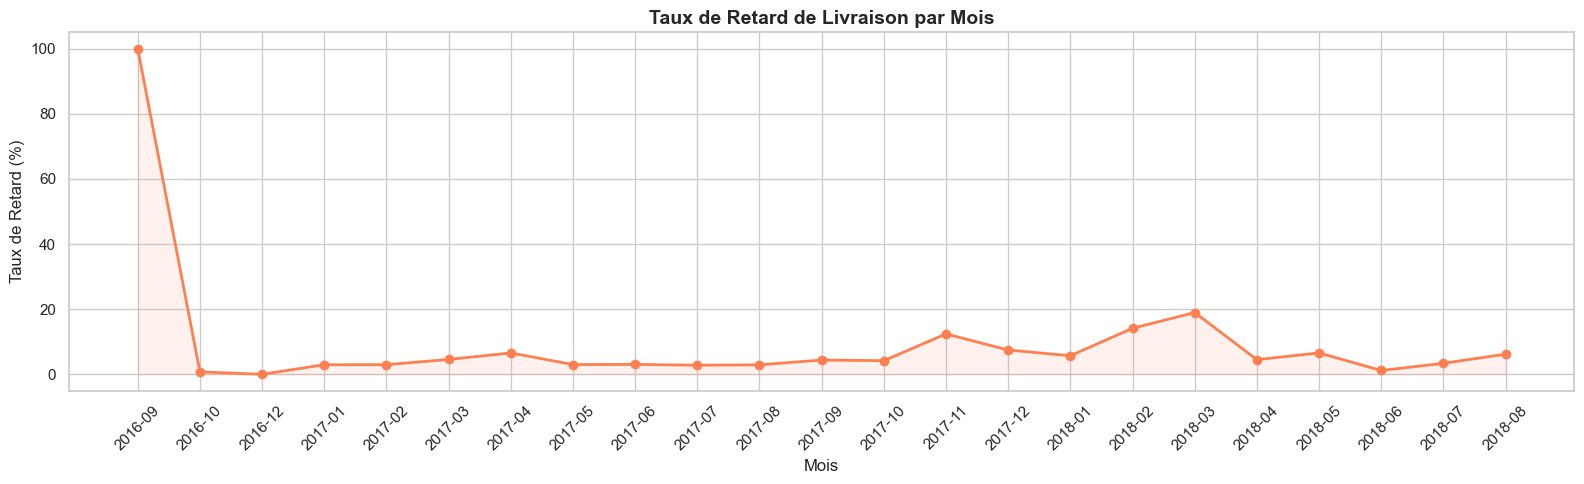

✓ eda_retard_mensuel.png sauvegardé


In [21]:
# =============================================================
# TAUX DE RETARD PAR MOIS
# =============================================================
retard_mensuel = (
    orders_delivery.groupby('order_month')
    .agg(nb_commandes=('order_id', 'count'), nb_retards=('is_late', 'sum'))
    .reset_index()
)
retard_mensuel['taux_retard']     = retard_mensuel['nb_retards'] / retard_mensuel['nb_commandes'] * 100
retard_mensuel['order_month_str'] = retard_mensuel['order_month'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(retard_mensuel['order_month_str'], retard_mensuel['taux_retard'],
        marker='o', color='coral', linewidth=2)
ax.fill_between(range(len(retard_mensuel)), retard_mensuel['taux_retard'],
                alpha=0.1, color='coral')
ax.set_title('Taux de Retard de Livraison par Mois', fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux de Retard (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_retard_mensuel.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_retard_mensuel.png sauvegard\u00e9')

## 4.7 - Corrélations & Heatmap

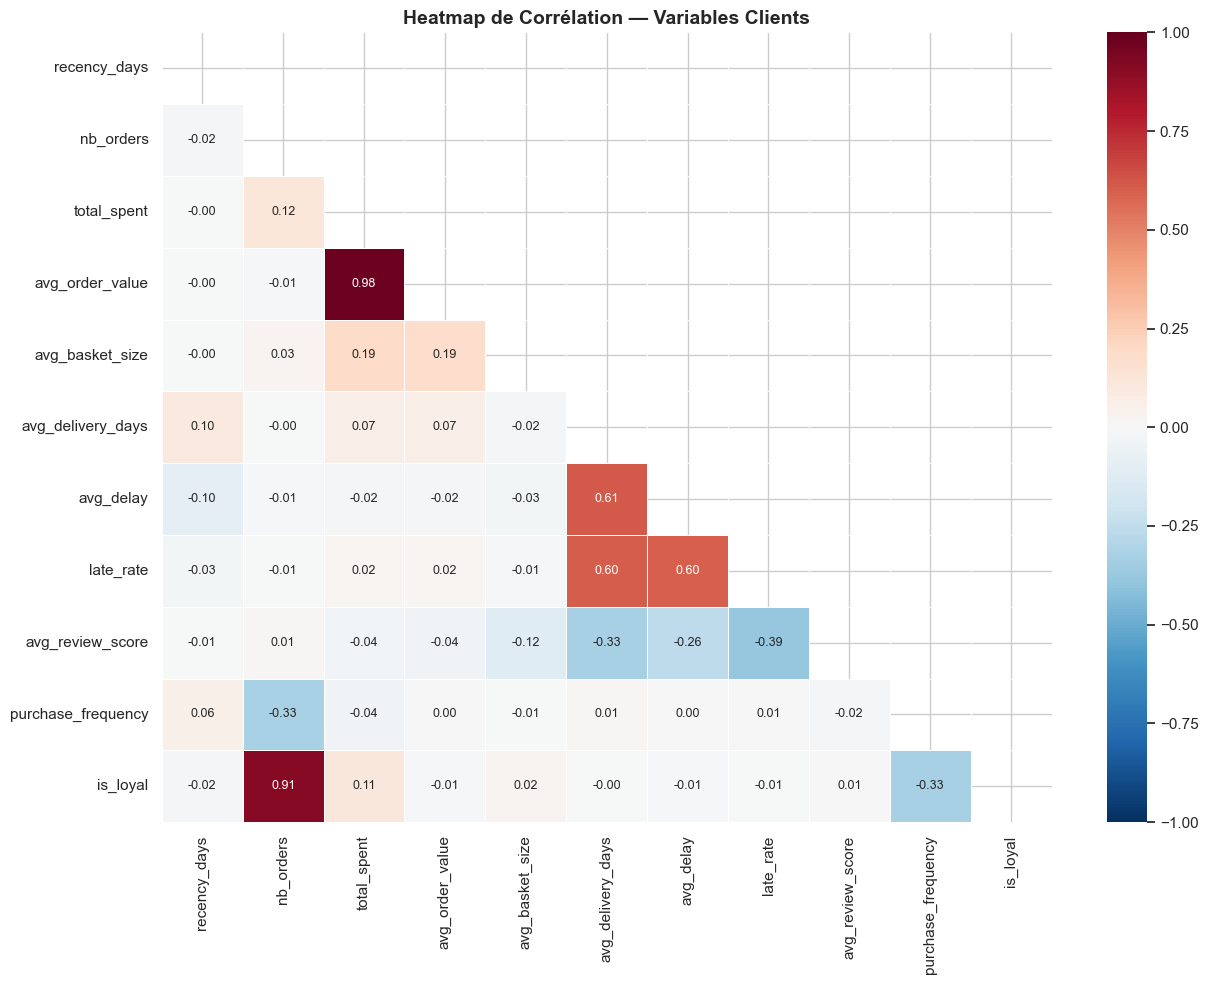

✓ eda_correlation_heatmap.png sauvegardé


In [22]:
# =============================================================
# HEATMAP DE CORRELATION — variables numeriques clients
# =============================================================
numeric_cols = [
    'recency_days', 'nb_orders', 'total_spent', 'avg_order_value',
    'avg_basket_size', 'avg_delivery_days', 'avg_delay',
    'late_rate', 'avg_review_score', 'purchase_frequency', 'is_loyal'
]

corr_matrix = ca[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
# Masque triangulaire superieur pour eviter la redondance
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, annot_kws={'size': 9}
)
ax.set_title('Heatmap de Corr\u00e9lation \u2014 Variables Clients',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_correlation_heatmap.png sauvegard\u00e9')

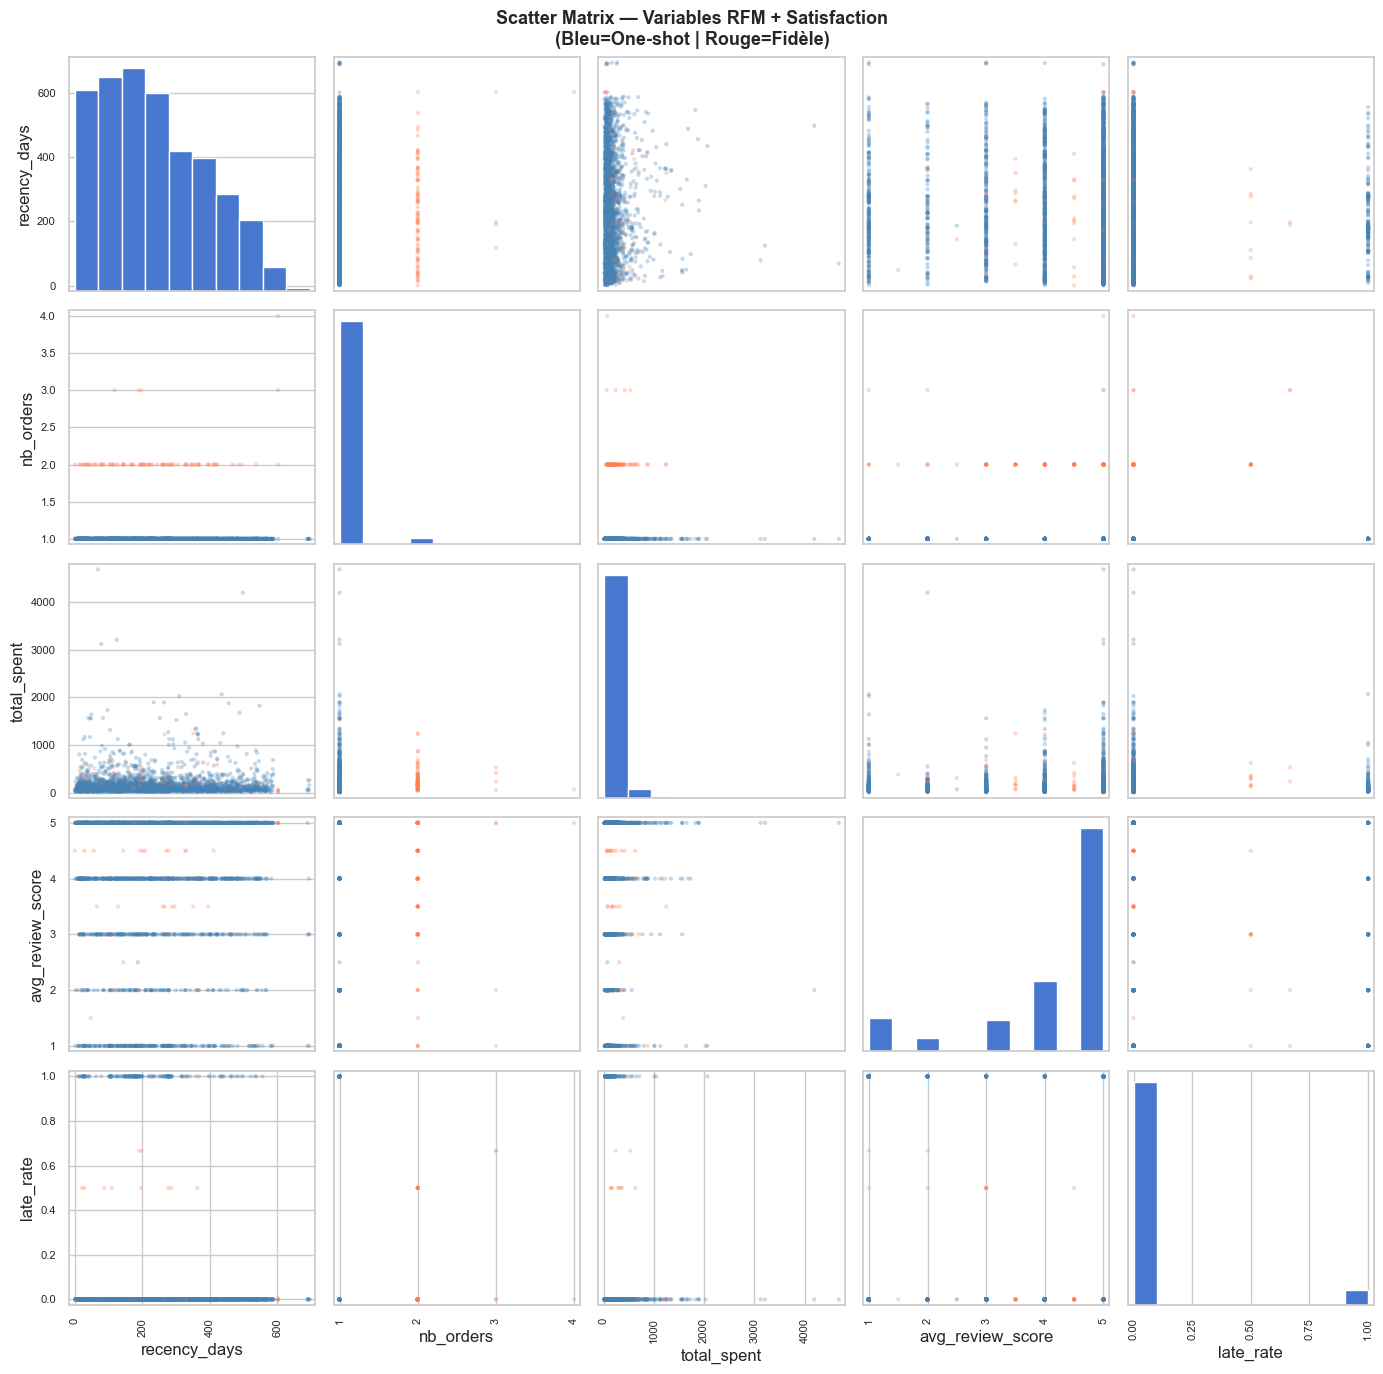

✓ eda_scatter_matrix.png sauvegardé


In [23]:
# =============================================================
# SCATTER MATRIX — variables RFM + satisfaction
# Bleu = clients one-shot | Rouge = clients fideles
# Echantillon de 3000 clients pour les performances
# =============================================================
scatter_cols = ['recency_days', 'nb_orders', 'total_spent',
                'avg_review_score', 'late_rate']

sample_ca      = ca[scatter_cols + ['is_loyal']].sample(min(3000, len(ca)), random_state=42)
colors_scatter = sample_ca['is_loyal'].map({0: 'steelblue', 1: 'coral'})

axes_sm = scatter_matrix(
    sample_ca[scatter_cols],
    alpha=0.3,
    color=colors_scatter,
    diagonal='hist',
    figsize=(14, 14)
)
plt.suptitle(
    'Scatter Matrix \u2014 Variables RFM + Satisfaction\n(Bleu=One-shot | Rouge=Fid\u00e8le)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_scatter_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_scatter_matrix.png sauvegard\u00e9')

## 4.8 - Détection des Outliers

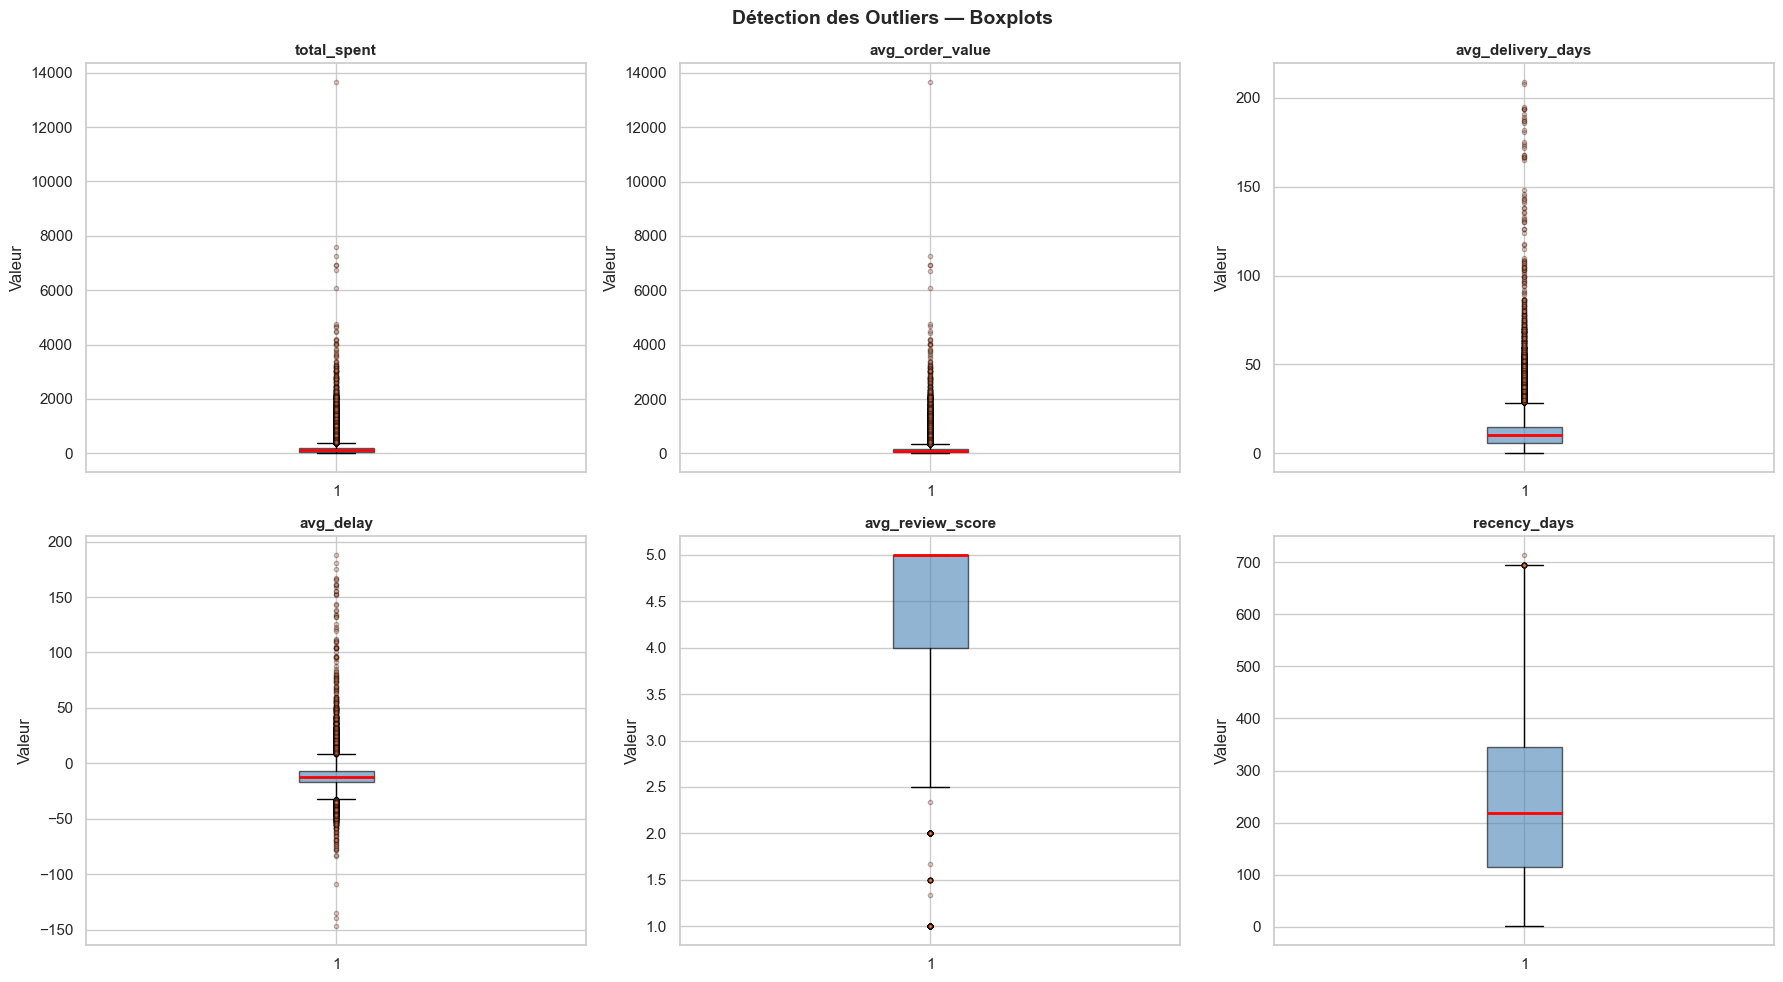

✓ eda_outliers_boxplot.png sauvegardé


In [24]:
# =============================================================
# BOXPLOTS — Detection visuelle des outliers sur variables cles
# =============================================================
outlier_cols = [
    'total_spent', 'avg_order_value', 'avg_delivery_days',
    'avg_delay', 'avg_review_score', 'recency_days'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, col in enumerate(outlier_cols):
    ax = axes[idx // 3, idx % 3]
    ax.boxplot(
        ca[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='coral', markersize=3, alpha=0.3)
    )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valeur')

plt.suptitle('D\u00e9tection des Outliers \u2014 Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_outliers_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_outliers_boxplot.png sauvegard\u00e9')

In [25]:
# =============================================================
# QUANTIFICATION OUTLIERS — Methode IQR
# Borne inferieure = Q1 - 1.5*IQR | Borne superieure = Q3 + 1.5*IQR
# =============================================================
print('=' * 70)
print('  OUTLIERS \u2014 M\u00c9THODE IQR')
print('=' * 70)

outlier_report = []
for col in outlier_cols:
    Q1    = ca[col].quantile(0.25)
    Q3    = ca[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((ca[col] < lower) | (ca[col] > upper)).sum()
    outlier_report.append({
        'Variable'    : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'IQR'         : round(IQR, 2),
        'Borne Inf'   : round(lower, 2),
        'Borne Sup'   : round(upper, 2),
        'Nb Outliers' : n_out,
        'Pct %'       : round(n_out / len(ca) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_report)
display(outlier_df)

  OUTLIERS — MÉTHODE IQR


,Variable,Q1,Q3,IQR,Borne Inf,Borne Sup,Nb Outliers,Pct %
0,total_spent,63.05,182.55,119.50,-116.20,361.79,7402,7.93
1,avg_order_value,62.37,176.65,114.28,-109.05,348.07,7332,7.85
2,avg_delivery_days,6.00,15.00,9.00,-7.50,28.50,4839,5.18
3,avg_delay,-17.00,-7.00,10.00,-32.00,8.00,4099,4.39
4,avg_review_score,4.00,5.00,1.00,2.50,6.50,11740,12.58
5,recency_days,114.00,346.00,232.00,-234.00,694.00,26,0.03


In [26]:
# =============================================================
# QUANTIFICATION OUTLIERS — Methode Z-Score (|z| > 3)
# =============================================================
print('=' * 70)
print('  OUTLIERS \u2014 M\u00c9THODE Z-SCORE (|z| > 3)')
print('=' * 70)

zscore_report = []
for col in outlier_cols:
    z_scores = np.abs(stats.zscore(ca[col].dropna()))
    n_out    = (z_scores > 3).sum()
    zscore_report.append({
        'Variable'    : col,
        'Nb Outliers' : n_out,
        'Pct %'       : round(n_out / len(ca) * 100, 2)
    })

display(pd.DataFrame(zscore_report))

  OUTLIERS — MÉTHODE Z-SCORE (|z| > 3)


,Variable,Nb Outliers,Pct %
0,total_spent,1614,1.73
1,avg_order_value,1624,1.74
2,avg_delivery_days,1551,1.66
3,avg_delay,1244,1.33
4,avg_review_score,0,0.00
5,recency_days,1,0.00


## 4.9 - Violin Plots

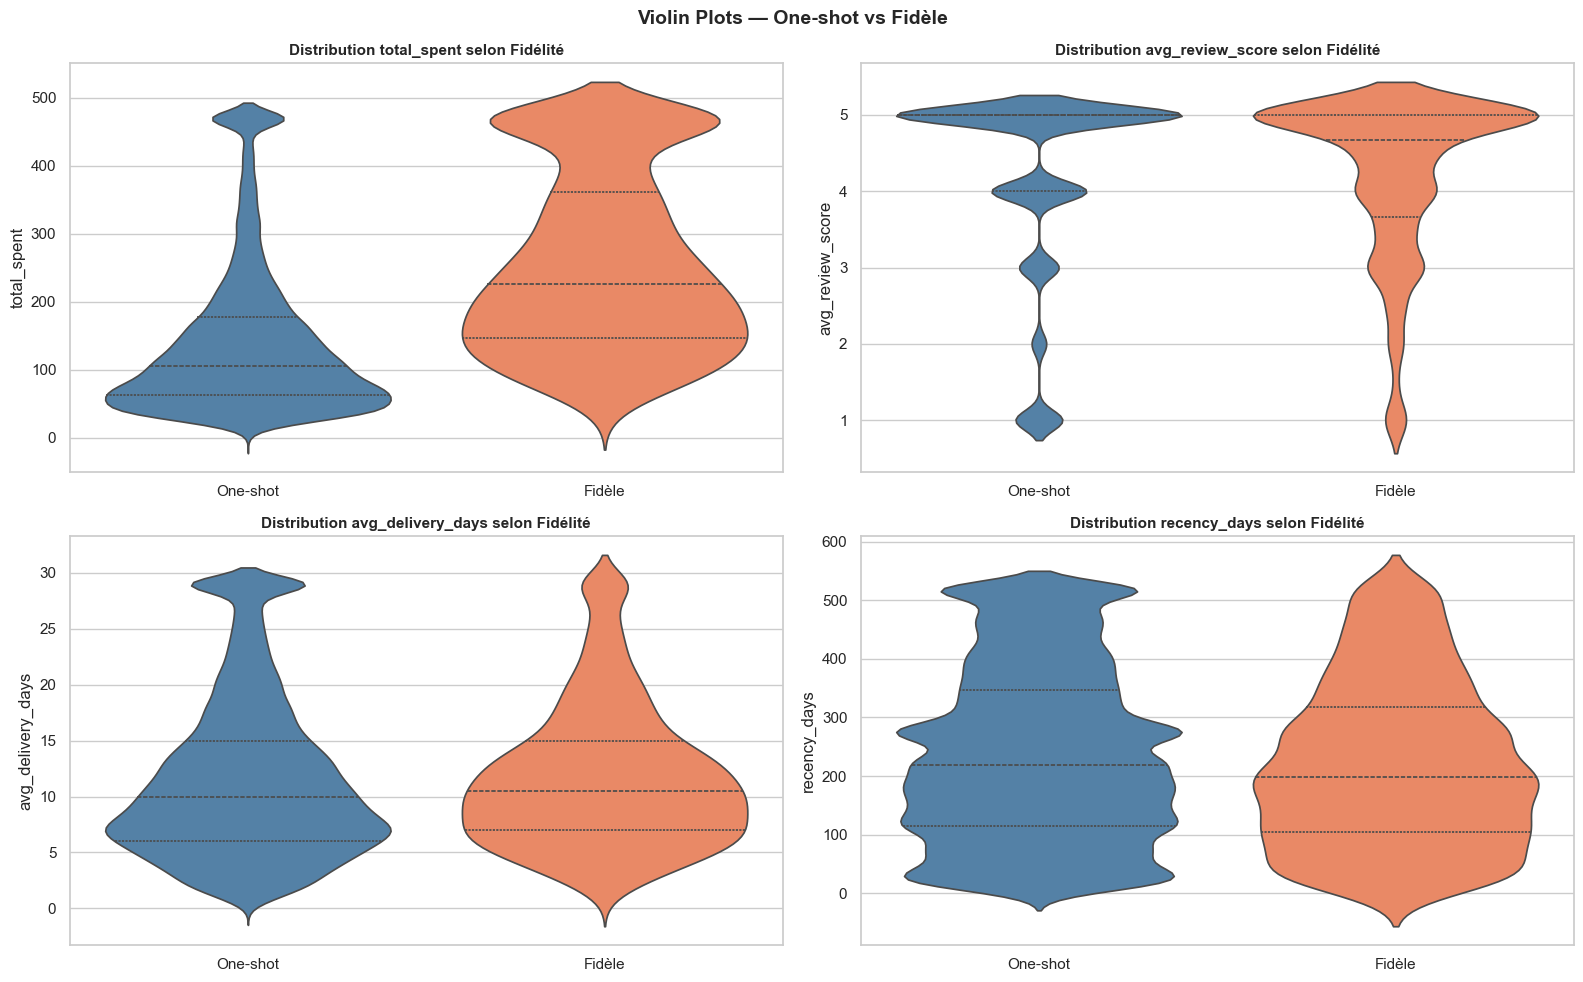

✓ eda_violin_plots.png sauvegardé


In [27]:
# =============================================================
# VIOLIN PLOTS — Distribution selon fidelite client
# Permet de comparer la forme complete de la distribution
# entre clients one-shot et clients fideles
# =============================================================
violin_cols = ['total_spent', 'avg_review_score', 'avg_delivery_days', 'recency_days']
ca['statut_client'] = ca['is_loyal'].map({0: 'One-shot', 1: 'Fid\u00e8le'})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, col in enumerate(violin_cols):
    ax = axes[idx // 2, idx % 2]
    # Cap au 95e percentile pour eviter que les outliers ecrasent le violin
    cap_val   = ca[col].quantile(0.95)
    data_plot = ca.copy()
    data_plot[col] = data_plot[col].clip(upper=cap_val)

    sns.violinplot(
        data=data_plot, x='statut_client', y=col,
        palette={'One-shot': 'steelblue', 'Fid\u00e8le': 'coral'},
        ax=ax, inner='quartile'
    )
    ax.set_title(f'Distribution {col} selon Fid\u00e9lit\u00e9', fontsize=11, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Violin Plots \u2014 One-shot vs Fid\u00e8le', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/eda_violin_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 eda_violin_plots.png sauvegard\u00e9')

## 4.10 - Synthèse EDA

In [28]:
# =============================================================
# SYNTHESE FINALE — Recapitulatif des KPIs et des graphiques
# =============================================================
print('=' * 60)
print('  SYNTH\u00c8SE EDA \u2014 INSIGHTS CL\u00c9S')
print('=' * 60)

print(f"""
VENTES
  CA total                : {ca_total:>15,.0f} BRL
  Nb commandes            : {nb_commandes:>15,}
  Panier moyen            : {panier_moyen:>15,.2f} BRL
  Meilleure cat\u00e9gorie CA  : {ca_categorie.iloc[0]['categorie']}

CLIENTS
  Nb clients uniques      : {len(ca):>15,}
  Taux de fid\u00e9lisation    : {ca['is_loyal'].mean()*100:>14.1f}%
  D\u00e9pense moyenne         : {ca['total_spent'].mean():>15,.2f} BRL
  R\u00e9cence moyenne         : {ca['recency_days'].mean():>14.0f} jours

SATISFACTION
  Note moyenne            : {note_moyenne:>14.2f} / 5
  % Avis positifs (\u22654)    : {pct_positif:>14.1f}%
  % Avis n\u00e9gatifs (\u22642)    : {pct_negatif:>14.1f}%

LIVRAISON
  D\u00e9lai moyen             : {delai_moyen:>14.1f} jours
  Taux de retard          : {taux_retard:>14.1f}%
  Retard moyen si retard  : {retard_moyen:>14.1f} jours
""")

graphs_saved = [
    'eda_ca_mensuel.png',           'eda_croissance_ca.png',
    'eda_ca_categorie.png',         'eda_distribution_clients.png',
    'eda_top_clients.png',          'eda_distribution_depenses.png',
    'eda_clients_par_etat.png',     'eda_top_produits_volume.png',
    'eda_produits_ca_vs_volume.png','eda_distribution_prix.png',
    'eda_satisfaction.png',         'eda_satisfaction_categorie.png',
    'eda_livraison_distribution.png','eda_retard_vs_satisfaction.png',
    'eda_retard_mensuel.png',       'eda_correlation_heatmap.png',
    'eda_scatter_matrix.png',       'eda_outliers_boxplot.png',
    'eda_violin_plots.png'
]

print(f'Graphiques sauvegard\u00e9s ({len(graphs_saved)}) :')
for g in graphs_saved:
    print(f'  \u2713 {g}')

print('\n\u2713 Phase 4 termin\u00e9e \u2014 pr\u00eat pour Phase 5 (Tests Statistiques)')

  SYNTHÈSE EDA — INSIGHTS CLÉS

VENTES
  CA total                :      15,422,462 BRL
  Nb commandes            :          96,478
  Panier moyen            :          159.85 BRL
  Meilleure catégorie CA  : health_beauty

CLIENTS
  Nb clients uniques      :          93,350
  Taux de fidélisation    :            3.0%
  Dépense moyenne         :          165.20 BRL
  Récence moyenne         :            238 jours

SATISFACTION
  Note moyenne            :           4.09 / 5
  % Avis positifs (≥4)    :           77.1%
  % Avis négatifs (≤2)    :           14.7%

LIVRAISON
  Délai moyen             :           12.1 jours
  Taux de retard          :            6.8%
  Retard moyen si retard  :           10.6 jours

Graphiques sauvegardés (19) :
  ✓ eda_ca_mensuel.png
  ✓ eda_croissance_ca.png
  ✓ eda_ca_categorie.png
  ✓ eda_distribution_clients.png
  ✓ eda_top_clients.png
  ✓ eda_distribution_depenses.png
  ✓ eda_clients_par_etat.png
  ✓ eda_top_produits_volume.png
  ✓ eda_produits_ca_vs_vol